In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Improve visuals
sns.set(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
file_path = "retail_sales_dataset.csv"
df = pd.read_csv(file_path)
print("Dataset Loaded Successfully!\n")

Dataset Loaded Successfully!



In [4]:
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Total Rows: 1000
Total Columns: 9


In [5]:
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 Rows of Data:")
display(df.head())


Column Names: ['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

First 5 Rows of Data:


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [6]:
print("\nDATASET INFORMATION:")
df.info()


DATASET INFORMATION:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [11]:
print("\nSUMMARY STATISTICS:")
display(df.describe())


SUMMARY STATISTICS:


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [12]:
print("\nCHECKING FOR MISSING VALUES:")
print(df.isnull().sum())


CHECKING FOR MISSING VALUES:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [14]:
# If Region column is not present, let's create one for demonstration
np.random.seed(42)
regions = ['North', 'South', 'East', 'West']
df['Region'] = np.random.choice(regions, size=len(df))

print("\nAdded 'Region' column for analysis.")
display(df.head())


Added 'Region' column for analysis.


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Region
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,East
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,West
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,North
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,East
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,East


In [15]:
# GROUP SALES DATA BY REGION
region_sales = df.groupby('Region')['Total Amount'].sum().reset_index().sort_values(by='Total Amount', ascending=False)

print("\nTOTAL SALES BY REGION:")
display(region_sales)


TOTAL SALES BY REGION:


,Region,Total Amount
3,West,125510
1,North,115285
0,East,107875
2,South,107330


C:\Users\VAIBHAV ADMANE\AppData\Local\Temp\ipykernel_29220\1255128709.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x='Region', y='Total Amount', palette='coolwarm', edgecolor="black")


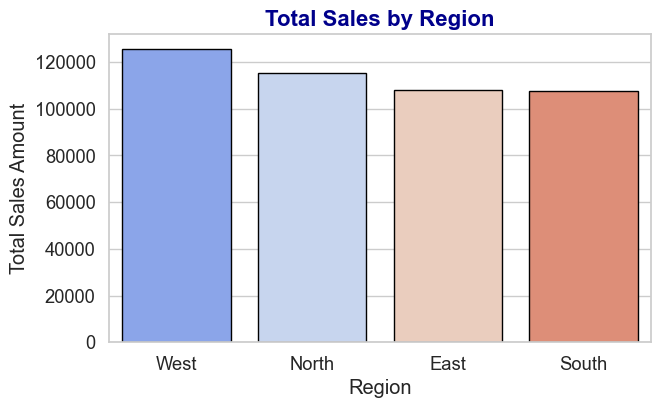

In [16]:
plt.figure(figsize=(7,4))
sns.barplot(data=region_sales, x='Region', y='Total Amount', palette='coolwarm', edgecolor="black")
plt.title("Total Sales by Region", fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel("Region")
plt.ylabel("Total Sales Amount")
plt.show()

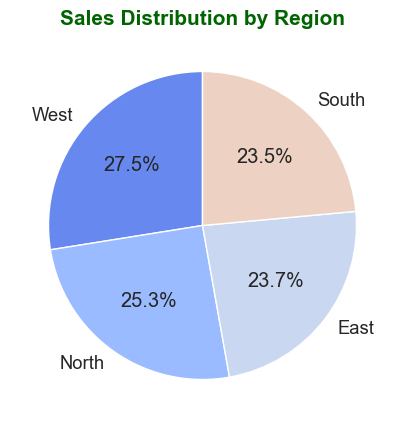

In [17]:
plt.figure(figsize=(5,5))
plt.pie(region_sales['Total Amount'], labels=region_sales['Region'], autopct='%1.1f%%',
        startangle=90, colors=sns.color_palette('coolwarm'))
plt.title("Sales Distribution by Region", fontsize=15, fontweight='bold', color='darkgreen')
plt.show()

In [18]:
top_region = region_sales.iloc[0]
print(f"\nTop Performing Region: {top_region['Region']} with Sales ${top_region['Total Amount']:.2f}")


Top Performing Region: West with Sales $125510.00


In [19]:
# GROUP SALES DATA BY REGION AND PRODUCT CATEGORY
region_category_sales = df.groupby(['Region', 'Product Category'])['Total Amount'].sum().reset_index()

print("\nTOTAL SALES BY REGION AND PRODUCT CATEGORY:")
display(region_category_sales.head(10))


TOTAL SALES BY REGION AND PRODUCT CATEGORY:


,Region,Product Category,Total Amount
0,East,Beauty,31225
1,East,Clothing,42880
2,East,Electronics,33770
3,North,Beauty,37460
4,North,Clothing,31425
5,North,Electronics,46400
6,South,Beauty,33980
7,South,Clothing,37610
8,South,Electronics,35740
9,West,Beauty,40850


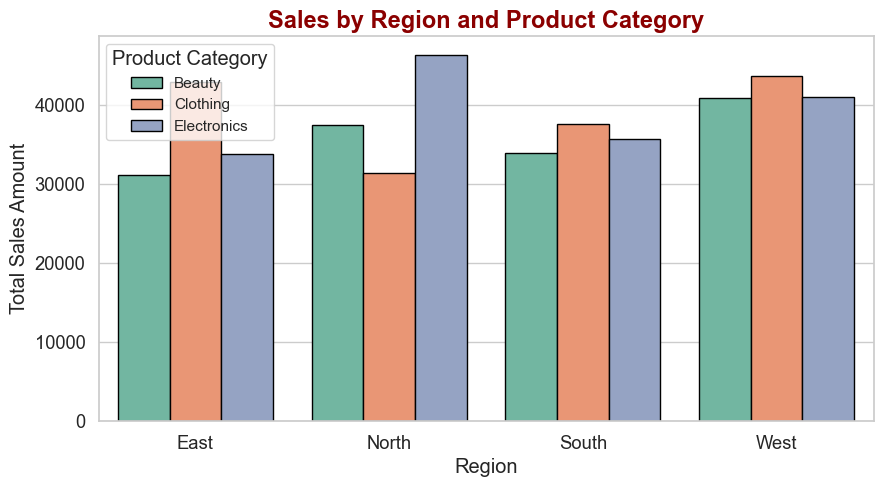

In [21]:
# VISUALIZE REGION + CATEGORY SALES
plt.figure(figsize=(10,5))
sns.barplot(data=region_category_sales, x='Region', y='Total Amount', hue='Product Category', palette='Set2', edgecolor='black')
plt.title("Sales by Region and Product Category", fontsize=17, fontweight='bold', color='darkred')
plt.xlabel("Region")
plt.ylabel("Total Sales Amount")
plt.legend(title='Product Category', fontsize=11)
plt.show()

In [23]:
print("Data Aggregation and Visualization Completed Successfully !!")
print("Analyzed total & category-wise sales by region, visualized them, & identified the top-performing region.")

Data Aggregation and Visualization Completed Successfully !!
Analyzed total & category-wise sales by region, visualized them, & identified the top-performing region.
